# 🧩 PARCIAL 3 — CLUSTERING (No Supervisado)
## Segmentación de Clientes — E-commerce Brasileño (Olist)

**Dataset:** Brazilian E-Commerce Public Dataset by Olist  
**Input:** `data/03_processed/df_processed_final.csv`  
**Fecha:** 27/01/2026
**Integrantes:** Antonio Sepúlveda



## 🎯 Objetivo
Aplicar **aprendizaje no supervisado** para **descubrir segmentos naturales de clientes**, sin usar una etiqueta objetivo (target).

### ¿Por qué clustering aquí?
- En supervisado (Notebooks 01–02) predecimos variables como `order_total_value` o `order_status`.
- En no supervisado (este Notebook 03) buscamos **patrones** y **grupos** sin una etiqueta, para entender perfiles de clientes y proponer acciones.

### Entregables
- Gráfico Elbow y Silhouette (guardados en `data/08_reporting/`)
- Dataset con cluster por cliente (`data/07_model_output/customer_clusters.csv`)
- Modelo + scaler (`data/06_models/`)
- Perfilado de clusters e interpretación de negocio (tablas y conclusiones)

## 1. Marco Conceptual (rúbrica)

### 1.1 Supervisado vs No Supervisado
- **Supervisado:** se entrena con una variable objetivo (Y) conocida (ej: regresión o clasificación).
- **No supervisado:** no existe Y; se busca estructura en los datos (ej: clustering, PCA, anomalías).

### 1.2 Casos de uso del aprendizaje no supervisado
- Segmentación de clientes (marketing, retención)
- Agrupación de productos (catálogo, recomendaciones)
- Detección de anomalías (fraude, pedidos atípicos)
- Reducción dimensionalidad para visualizar patrones

### 1.3 Ventajas y desventajas
- ✅ Ventajas: no requiere etiquetas, descubre patrones nuevos.
- ⚠️ Desventajas: validación más difícil, elección de K puede ser subjetiva, interpretación requiere criterio.

## 2. Configuración e Imports
En esta sección se importan librerías y se definen rutas. Todo lo que se genera se guarda en carpetas del proyecto.

In [ ]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import joblib

# =============================
# Rutas y parámetros del proyecto
# =============================
INPUT_PATH = "../data/03_processed/df_processed_final.csv"

REPORT_DIR = "data/08_reporting"
MODEL_DIR = "data/06_models"
OUTPUT_DIR = "data/07_model_output"
OUTPUT_CLUSTERS_CSV = os.path.join(OUTPUT_DIR, "customer_clusters.csv")
OUTPUT_CUSTOMER_TABLE = os.path.join(OUTPUT_DIR, "customer_features_for_clustering.csv")
OUTPUT_CLUSTERS = os.path.join(OUTPUT_DIR, "customer_clusters.csv")

ELBOW_PNG = os.path.join(REPORT_DIR, "03_elbow_curve.png")
SIL_PNG = os.path.join(REPORT_DIR, "03_silhouette_curve.png")
CLUSTER_SIZES_PNG = os.path.join(REPORT_DIR, "03_cluster_sizes.png")

SCALER_PATH = os.path.join(MODEL_DIR, "03_scaler_customer.joblib")
KMEANS_PATH = os.path.join(MODEL_DIR, "03_kmeans_customer.joblib")

# Path para guardar el modelo PCA
PCA_PATH = os.path.join(MODEL_DIR, "03_pca_customer.joblib")

# =============================
# Outputs extra para evidencia
# =============================
METRICS_BY_K_CSV = os.path.join(OUTPUT_DIR, "metrics_by_k.csv")
CLUSTER_PROFILES_CSV = os.path.join(OUTPUT_DIR, "cluster_profiles.csv")
CLUSTER_NAMING_CSV = os.path.join(OUTPUT_DIR, "cluster_naming.csv")
EXEC_SUMMARY_TXT = os.path.join(OUTPUT_DIR, "clustering_executive_summary.txt")

CORR_PNG = os.path.join(REPORT_DIR, "03_corr_heatmap.png")
DIST_PNG = os.path.join(REPORT_DIR, "03_feature_distributions.png")
BOX_PNG = os.path.join(REPORT_DIR, "03_feature_boxplots.png")
PCA_PNG = os.path.join(REPORT_DIR, "03_pca_clusters.png")
K_COMBINED_PNG = os.path.join(REPORT_DIR, "03_k_selection_combined.png")
MODEL_COMPARE_CSV = os.path.join(OUTPUT_DIR, "model_comparison.csv")

print("✅ Paths extra listos")

K_MIN = 2
K_MAX = 10
RANDOM_STATE = 42

os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Configuración lista")

✅ Paths extra listos
✅ Configuración lista


## 2.3 Validación del entorno y rutas (sanity check)


Antes de continuar, verificamos que:


- El archivo de entrada (`INPUT_PATH`) existe.
- Las carpetas de salida están creadas (`REPORT_DIR`, `MODEL_DIR`, `OUTPUT_DIR`).
- Las rutas de evidencias están definidas correctamente.


Esto evita errores más adelante y asegura reproducibilidad.

In [7]:
# =========================================
# 2.3 Validación del entorno y rutas
# =========================================

# Verificar que exista el dataset de entrada
if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f"❌ No se encontró el archivo de entrada: {INPUT_PATH}\n"
        "➡️ Verifica que exista en data/03_processed/ y que el nombre sea correcto."
    )

print("✅ INPUT_PATH existe:", INPUT_PATH)

# Verificar carpetas de salida
for d in [REPORT_DIR, MODEL_DIR, OUTPUT_DIR]:
    if not os.path.exists(d):
        raise FileNotFoundError(f"❌ Falta la carpeta requerida: {d}")
    print("✅ Carpeta OK:", d)

# Mostrar un resumen de outputs (para trazabilidad)
print("\n📁 Outputs principales (se generarán durante el notebook):")
print("- Gráficos:", REPORT_DIR)
print("- Modelos:", MODEL_DIR)
print("- Resultados:", OUTPUT_DIR)

print("\n🧾 Rutas clave:")
print("METRICS_BY_K_CSV:", METRICS_BY_K_CSV)
print("CLUSTER_PROFILES_CSV:", CLUSTER_PROFILES_CSV)
print("CLUSTER_NAMING_CSV:", CLUSTER_NAMING_CSV)
print("EXEC_SUMMARY_TXT:", EXEC_SUMMARY_TXT)
print("CORR_PNG:", CORR_PNG)
print("DIST_PNG:", DIST_PNG)
print("BOX_PNG:", BOX_PNG)
print("PCA_PNG:", PCA_PNG)
print("K_COMBINED_PNG:", K_COMBINED_PNG)
print("MODEL_COMPARE_CSV:", MODEL_COMPARE_CSV)

print("\n✅ Validación completada. Puedes continuar a la Sección 3.")

✅ INPUT_PATH existe: ../data/03_processed/df_processed_final.csv
✅ Carpeta OK: data/08_reporting
✅ Carpeta OK: data/06_models
✅ Carpeta OK: data/07_model_output

📁 Outputs principales (se generarán durante el notebook):
- Gráficos: data/08_reporting
- Modelos: data/06_models
- Resultados: data/07_model_output

🧾 Rutas clave:
METRICS_BY_K_CSV: data/07_model_output\metrics_by_k.csv
CLUSTER_PROFILES_CSV: data/07_model_output\cluster_profiles.csv
CLUSTER_NAMING_CSV: data/07_model_output\cluster_naming.csv
EXEC_SUMMARY_TXT: data/07_model_output\clustering_executive_summary.txt
CORR_PNG: data/08_reporting\03_corr_heatmap.png
DIST_PNG: data/08_reporting\03_feature_distributions.png
BOX_PNG: data/08_reporting\03_feature_boxplots.png
PCA_PNG: data/08_reporting\03_pca_clusters.png
K_COMBINED_PNG: data/08_reporting\03_k_selection_combined.png
MODEL_COMPARE_CSV: data/07_model_output\model_comparison.csv

✅ Validación completada. Puedes continuar a la Sección 3.


## 3. Carga del dataset procesado
Se carga el dataset final ya procesado para asegurar consistencia con las fases anteriores (CRISP-DM).

In [8]:
df = pd.read_csv(INPUT_PATH)
print("✅ Dataset cargado")
print("Dimensiones:", df.shape)
display(df.head())

# Revisar valores faltantes y duplicados
missing = df.isna().sum().sum()
dups = df.duplicated().sum()
print("Total missing:", missing)
print("Duplicados:", dups)

✅ Dataset cargado
Dimensiones: (119143, 134)


,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code,customer_city,...,customer_geolocation_state_Rn,customer_geolocation_state_Ro,customer_geolocation_state_Rr,customer_geolocation_state_Rs,customer_geolocation_state_Sc,customer_geolocation_state_Se,customer_geolocation_state_Sp,customer_geolocation_state_To,order_total_value_segment_Medium,order_total_value_segment_High
0,E481F51Cbdc54678B7Cc49136F2D6Af7,9Ef432Eb6251297304E76186B10A928D,2017-10-02 10:56:33,-0.739592,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7C396Fd4830Fd04220F754E42B4E5Bff,-1.069120,1.002740,...,False,False,False,False,False,False,True,False,False,False
1,E481F51Cbdc54678B7Cc49136F2D6Af7,9Ef432Eb6251297304E76186B10A928D,2017-10-02 10:56:33,-0.739592,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7C396Fd4830Fd04220F754E42B4E5Bff,-1.069120,1.002740,...,False,False,False,False,False,False,True,False,False,False
2,E481F51Cbdc54678B7Cc49136F2D6Af7,9Ef432Eb6251297304E76186B10A928D,2017-10-02 10:56:33,-0.739592,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7C396Fd4830Fd04220F754E42B4E5Bff,-1.069120,1.002740,...,False,False,False,False,False,False,True,False,False,False
3,53Cdb2Fc8Bc7Dce0B6741E2150273451,B0830Fb4747A6C6D20Dea0B8C802D7Ef,2018-07-24 20:41:37,1.439568,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,Af07308B275D755C9Edb36A90C618231,0.428512,-1.623052,...,False,False,False,False,False,False,False,False,False,True
4,47770Eb9100C2D0C44946D9Cf07Ec65D,41Ce2A54C0B03Bf3443C3D931A367089,2018-08-08 08:38:49,1.559634,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3A653A41F6F9Fc3D2A113Cf8398680E8,1.349007,1.376909,...,False,False,False,False,False,False,False,False,False,True


Total missing: 0
Duplicados: 11309


### 3.2 Validación de columnas mínimas

Antes de continuar, se valida que el dataset contenga las columnas esenciales
para la construcción del dataset de clustering a nivel cliente.

Estas columnas son necesarias para:
- Identificar clientes
- Contar órdenes
- Calcular recency, frequency y monetary
- Mantener coherencia con los notebooks anteriores

In [9]:
# =========================================
# 3.2 Validación de columnas mínimas
# =========================================

required_columns = [
    "customer_unique_id",
    "order_id",
    "order_purchase_timestamp",
    "order_total_value"
]

missing_cols = [c for c in required_columns if c not in df.columns]

if missing_cols:
    raise ValueError(
        f"❌ Faltan columnas obligatorias en el dataset: {missing_cols}\n"
        "➡️ Revisa el preprocesamiento de los notebooks 01 y 02."
    )

print("✅ Columnas mínimas presentes:")
for c in required_columns:
    print(" -", c)

# Verificación adicional de tipos críticos
print("\n📌 Tipos de datos relevantes:")
print(df[required_columns].dtypes)

✅ Columnas mínimas presentes:
 - customer_unique_id
 - order_id
 - order_purchase_timestamp
 - order_total_value

📌 Tipos de datos relevantes:
customer_unique_id           object
order_id                     object
order_purchase_timestamp     object
order_total_value           float64
dtype: object


### 3.3 Identificación del nivel del dataset


A partir de la inspección del dataset, se observa que:


- Cada fila **no representa un cliente único**, sino una combinación asociada a pedidos y/o ítems.
- Un mismo `customer_unique_id` puede aparecer múltiples veces en el dataset.
- Esto explica la presencia de registros duplicados detectados en la sección 3.1.


Para realizar un **clustering significativo**, es necesario definir claramente la entidad a segmentar.
En este proyecto, la entidad seleccionada es el **cliente**, por lo que en la siguiente sección
se construirá un nuevo dataset agregado a nivel cliente.


Este enfoque permite:
- Interpretar los clusters como **perfiles de clientes**
- Proponer **acciones de negocio concretas**
- Mantener coherencia con los objetivos del proyecto

In [10]:
# =========================================
# 3.3 Confirmación técnica del nivel del dataset
# =========================================

# Número de clientes únicos
n_customers = df["customer_unique_id"].nunique()

# Número de órdenes únicas
n_orders = df["order_id"].nunique()

print("📊 Nivel del dataset:")
print(f"- Filas totales: {len(df)}")
print(f"- Clientes únicos: {n_customers}")
print(f"- Órdenes únicas: {n_orders}")

if n_orders > n_customers:
    print("➡️ El dataset se encuentra a nivel pedido/ítem.")
    print("➡️ Se requiere agregación para clustering a nivel cliente.")
else:
    print("➡️ El dataset ya se encuentra a nivel cliente.")

📊 Nivel del dataset:
- Filas totales: 119143
- Clientes únicos: 96096
- Órdenes únicas: 99441
➡️ El dataset se encuentra a nivel pedido/ítem.
➡️ Se requiere agregación para clustering a nivel cliente.


## 4. Construcción del dataset para clustering (nivel cliente)
Aunque el dataset base puede estar a nivel de pedido/item, para la **segmentación de clientes** se agregan variables por `customer_unique_id`.

Esto permite:
- interpretar clusters como *perfiles de clientes*
- proponer acciones de negocio (marketing/retención)

In [11]:
# Convertir timestamp a datetime (para calcular recency)
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")

# Definir columna de cliente
customer_col = "customer_unique_id"
if customer_col not in df.columns:
    raise ValueError("No existe customer_unique_id en el dataset")

# Fecha de referencia para recency: máximo timestamp del dataset
ref_date = df["order_purchase_timestamp"].max()
print("Fecha de referencia (última compra registrada):", ref_date)

# Variables base para construir comportamiento por cliente
# (Usamos variables numéricas/operacionales presentes en tu header)
base_numeric_cols = [
    "order_total_value",
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "review_score",
    "days_to_delivery",
    "order_purchase_is_weekend"
]

# Filtrar solo las que realmente existan
base_numeric_cols = [c for c in base_numeric_cols if c in df.columns]
print("Columnas base usadas:", base_numeric_cols)

# Agregaciones por cliente
g = df.groupby(customer_col)

# Recency (días desde última compra)
last_purchase = g["order_purchase_timestamp"].max()
recency_days = (ref_date - last_purchase).dt.days.rename("recency_days")

# Frequency (# órdenes distintas)
# order_id existe, lo usamos para contar órdenes
freq_orders = g["order_id"].nunique().rename("frequency_orders")

# Monetary (gasto total)
monetary_total = g["order_total_value"].sum().rename("monetary_total") if "order_total_value" in df.columns else None
monetary_avg = g["order_total_value"].mean().rename("monetary_avg") if "order_total_value" in df.columns else None

# Otras medias útiles
agg_means = {}
for c in base_numeric_cols:
    if c not in ["order_total_value"]:
        agg_means[c + "_mean"] = g[c].mean()

# Construcción del dataframe final de clientes
customer_df = pd.concat([
    recency_days,
    freq_orders,
    monetary_total if monetary_total is not None else pd.Series(dtype=float),
    monetary_avg if monetary_avg is not None else pd.Series(dtype=float),
    *[v.rename(k) for k, v in agg_means.items()]
], axis=1)

# Limpiar posibles NaN (por fechas faltantes)
customer_df = customer_df.replace([np.inf, -np.inf], np.nan)
customer_df = customer_df.dropna(axis=0)

print("✅ customer_df listo")
print("Dimensiones customer_df:", customer_df.shape)
display(customer_df.head())

# Guardar features de clientes para trazabilidad
customer_df.to_csv(OUTPUT_CUSTOMER_TABLE, index=True)
print("✅ Guardado:", OUTPUT_CUSTOMER_TABLE)

Fecha de referencia (última compra registrada): 2018-10-17 17:30:18
Columnas base usadas: ['order_total_value', 'price', 'freight_value', 'payment_value', 'payment_installments', 'review_score', 'days_to_delivery', 'order_purchase_is_weekend']
✅ customer_df listo
Dimensiones customer_df: (96096, 11)


,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean
customer_unique_id,,,,,,,,,,,
0000366F3B9A7992Bf8C76Cfdf3221E2,160,1,0.458720,0.458720,0.476111,-0.787328,0.371636,0.941176,0.779134,-0.732287,0.0
0000B849F77A49E4A4Ce2B2A4Ca5Be3F,163,1,0.071297,0.071297,0.066593,-1.288506,0.071211,0.117647,-0.240039,-1.142083,0.0
0000F46A3911Fa3C0805444483337064,585,1,0.270666,0.270666,0.251430,-0.082168,0.225810,0.941176,-1.259212,1.863083,0.0
0000F6Ccb0745A6A4B88665A16C9F078,369,1,0.126788,0.126788,0.092750,-0.026782,0.114241,0.470588,-0.240039,1.180091,0.0
0004Aac84E0Df4Da2B147Fca70Cf8255,336,1,0.644443,0.644443,0.660948,-0.126747,0.515655,0.705882,0.779134,0.223902,0.0


✅ Guardado: data/07_model_output\customer_features_for_clustering.csv


### 4.1 Revisión final del dataset de clientes

Antes de aplicar clustering, se revisa el dataset agregado a nivel cliente para confirmar:

- dimensiones (número de clientes y variables)
- ausencia de valores faltantes
- estadísticos descriptivos básicos

Esto asegura consistencia antes del escalado y modelado.

In [ ]:
# =========================================
# 4.1 Revisión final del dataset de clientes
# =========================================

print("📊 Dimensiones (clientes, variables):", customer_df.shape)

print("\n🔍 Missing values por columna (top 10):")
missing_per_col = customer_df.isna().sum().sort_values(ascending=False)
display(missing_per_col.head(10))

total_missing = int(customer_df.isna().sum().sum())
print("\nTotal missing en customer_df:", total_missing)

print("\n📈 Estadísticas descriptivas:")
display(customer_df.describe())

# Si hay missing (idealmente 0), dejamos una alerta clara
if total_missing > 0:
    print("⚠️ Hay valores faltantes. Se recomienda revisarlos antes de escalar/clustering.")
else:
    print("✅ Sin valores faltantes. Listo para escalado y clustering.")

📊 Dimensiones (clientes, variables): (96096, 11)

🔍 Missing values por columna (top 10):


recency_days                 0
frequency_orders             0
monetary_total               0
monetary_avg                 0
price_mean                   0
freight_value_mean           0
payment_value_mean           0
payment_installments_mean    0
review_score_mean            0
days_to_delivery_mean        0
dtype: int64


Total missing en customer_df: 0

📈 Estadísticas descriptivas:


,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean
count,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.0
mean,287.735691,1.034809,0.458033,0.381568,0.370152,0.018876,0.352042,0.329545,0.044458,0.006341,0.0
std,153.414676,0.214384,0.445131,0.265673,0.278258,0.976538,0.259542,0.282891,0.969193,1.003134,0.0
min,0.000000,1.000000,0.013476,0.011015,0.000000,-2.276676,0.000000,0.000000,-1.768799,-1.551878,0.0
25%,163.000000,1.000000,0.194497,0.175321,0.155483,-0.599556,0.159366,0.117647,-0.240039,-0.732287,0.0
50%,268.000000,1.000000,0.345061,0.301062,0.288323,-0.199695,0.271944,0.235294,0.779134,-0.185894,0.0
75%,397.000000,1.000000,0.598190,0.520374,0.513005,0.448729,0.458934,0.470588,0.779134,0.497098,0.0
max,772.000000,17.000000,29.000000,1.000000,1.000000,2.083971,1.000000,1.000000,0.779134,2.341177,0.0


✅ Sin valores faltantes. Listo para escalado y clustering.


## 5. Exploración visual (EDA ligera)

Antes de aplicar técnicas de clustering, se realiza una exploración visual
ligera del dataset agregado a nivel cliente con el objetivo de:

- analizar la distribución de las variables
- identificar posibles outliers
- evaluar correlaciones entre features
- justificar la necesidad de escalado y reducción dimensional

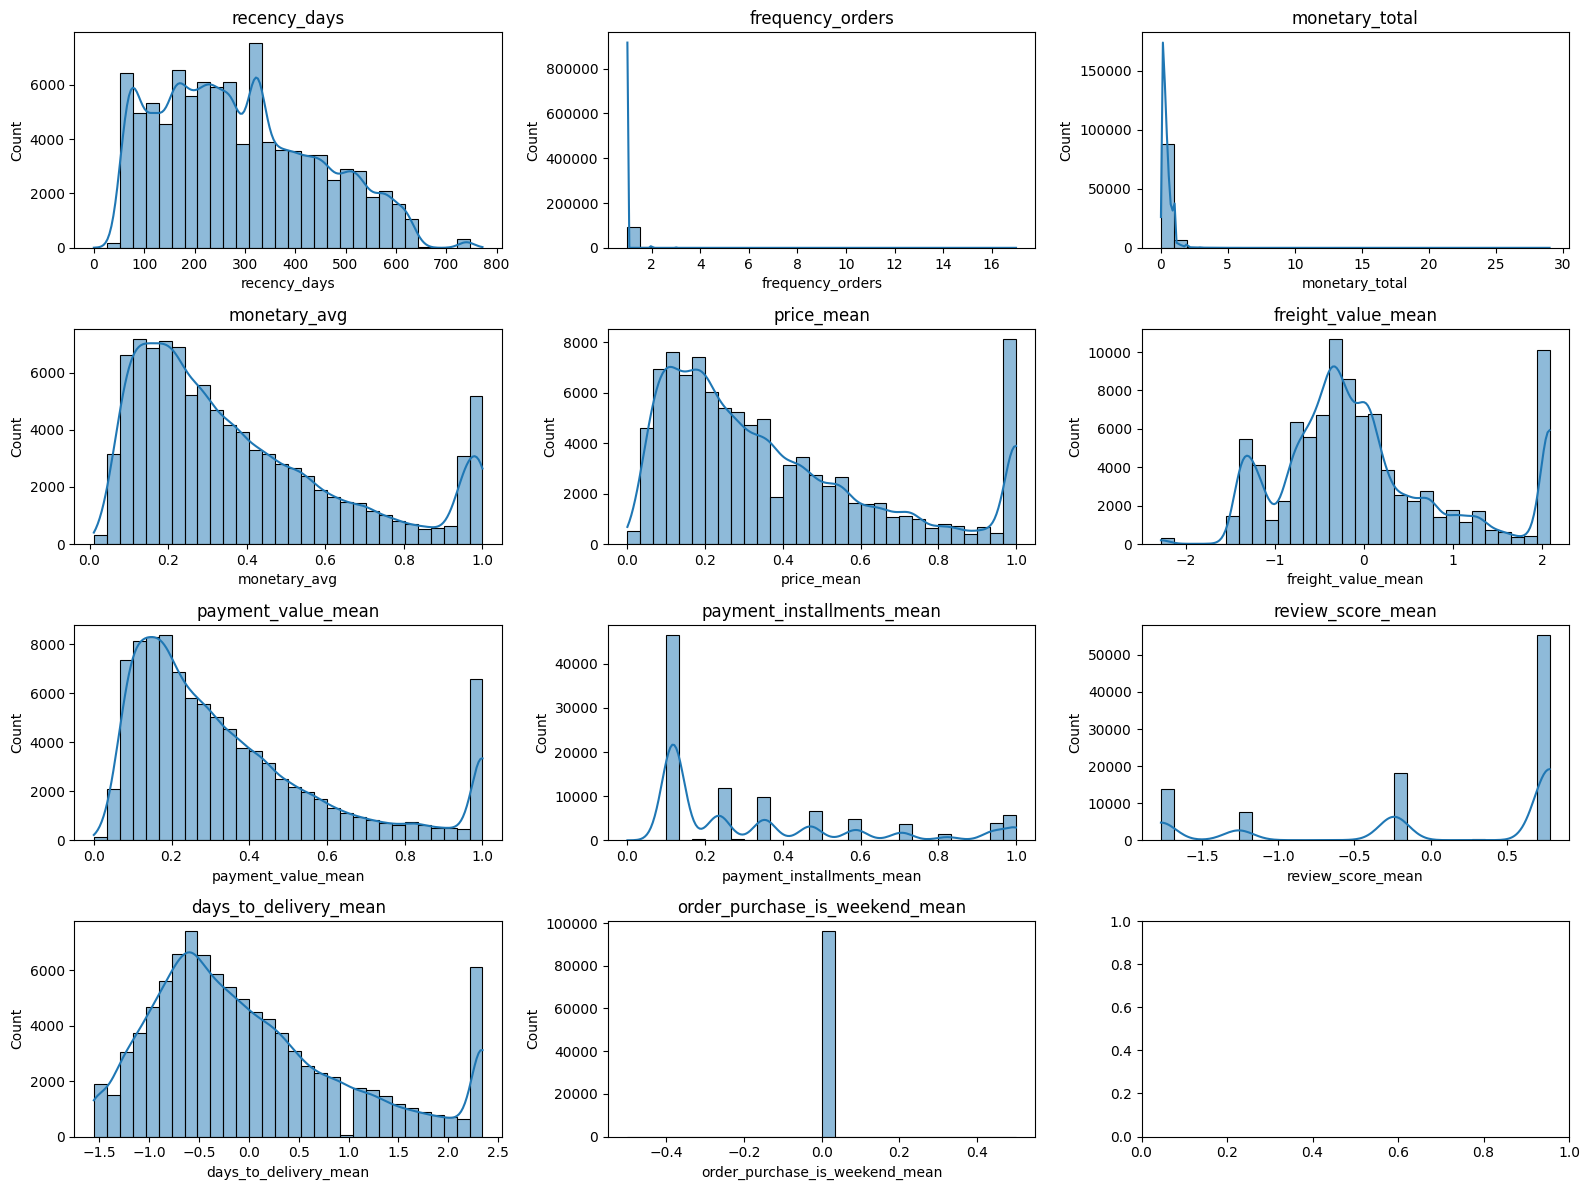

📊 Gráfico de distribuciones guardado en: data/08_reporting\03_feature_distributions.png


In [13]:
# =========================================
# 5.1 Distribución de variables clave
# =========================================

features_to_plot = customer_df.columns.tolist()

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.histplot(customer_df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig(DIST_PNG)
plt.show()

print("📊 Gráfico de distribuciones guardado en:", DIST_PNG)

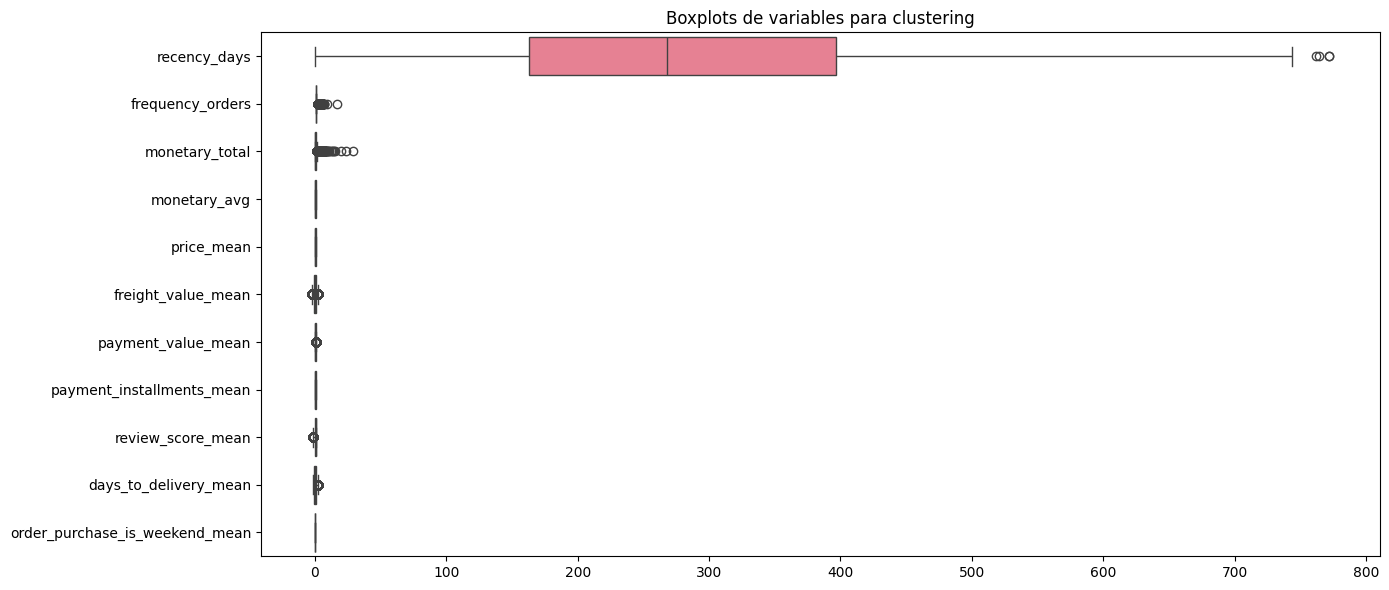

📦 Boxplots guardados en: data/08_reporting\03_feature_boxplots.png


In [14]:
# =========================================
# 5.2 Boxplots para detección de outliers
# =========================================

plt.figure(figsize=(14, 6))
sns.boxplot(data=customer_df, orient="h")
plt.title("Boxplots de variables para clustering")
plt.tight_layout()
plt.savefig(BOX_PNG)
plt.show()

print("📦 Boxplots guardados en:", BOX_PNG)

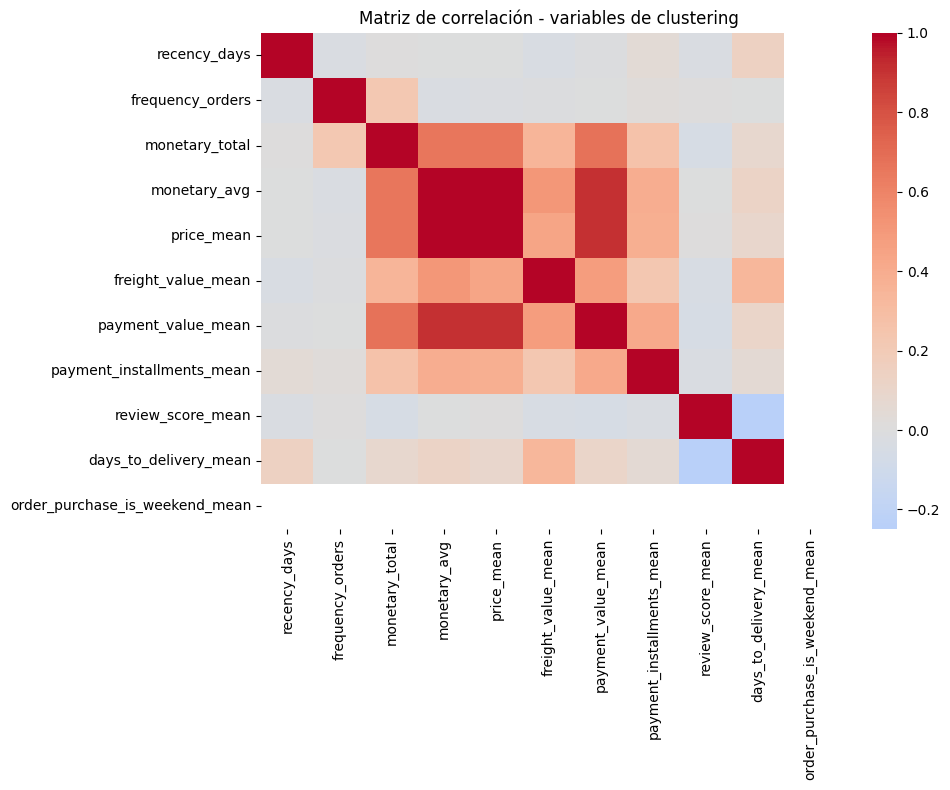

🔗 Heatmap de correlación guardado en: data/08_reporting\03_corr_heatmap.png


In [15]:
# =========================================
# 5.3 Matriz de correlación
# =========================================

corr = customer_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación - variables de clustering")
plt.tight_layout()
plt.savefig(CORR_PNG)
plt.show()

print("🔗 Heatmap de correlación guardado en:", CORR_PNG)

## 6. Preparación para clustering (escalado)

In [16]:
# Seleccionar features numéricas
X = customer_df.copy()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Guardar scaler
joblib.dump(scaler, SCALER_PATH)
print("✅ Scaler guardado:", SCALER_PATH)

print("Matriz escalada:", X_scaled.shape)

✅ Scaler guardado: data/06_models\03_scaler_customer.joblib
Matriz escalada: (96096, 11)


### 6.2 Reducción de dimensionalidad (PCA)

Componentes PCA: 6
Varianza explicada acumulada: 0.9017668189530748


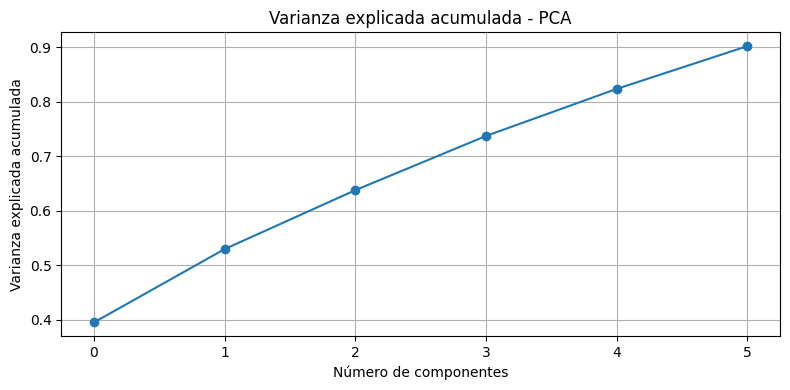

In [19]:
from sklearn.decomposition import PCA

# Aplicar PCA conservando 90% de varianza
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Componentes PCA:", pca.n_components_)
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

# Guardar PCA
joblib.dump(pca, PCA_PATH)

# Gráfico de varianza explicada
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada - PCA")
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "03_pca_variance.png"))
plt.show()

## 7. Selección del número óptimo de clusters (K)
Se usan dos criterios:
- **Elbow:** inercia (SSE) disminuye con K, buscamos un "codo".
- **Silhouette:** mide separación/cohesión (más alto suele ser mejor).

> En la decisión final se considera métrica + sentido de negocio.

,k,inertia,silhouette
0,2,691975.768961,0.332651
1,3,623711.747242,0.196567
2,4,571738.802446,0.188695
3,5,498891.247568,0.202232
4,6,465379.182077,0.169417
5,7,438361.848511,0.177180
6,8,418606.866424,0.179625
7,9,397171.512831,0.181162
8,10,379533.857348,0.182697


📄 Tabla metrics_by_k guardada en: data/07_model_output\metrics_by_k.csv


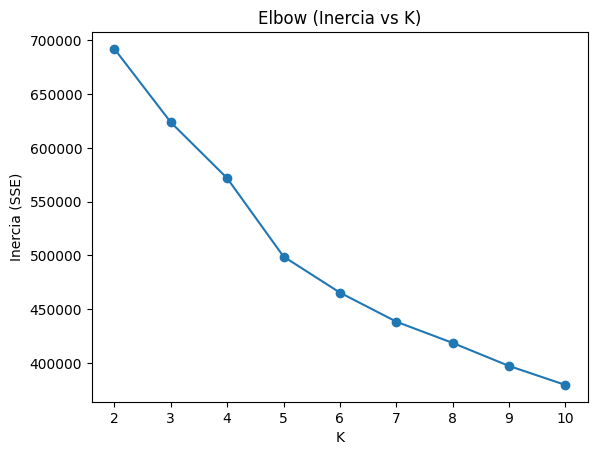

✅ Guardado Elbow: data/08_reporting\03_elbow_curve.png


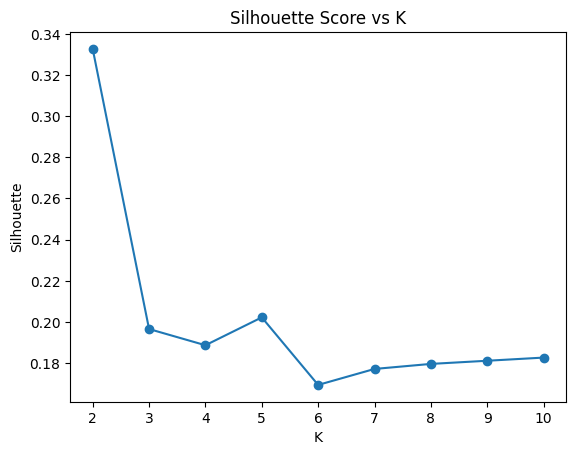

✅ Guardado Silhouette: data/08_reporting\03_silhouette_curve.png
✅ K elegido (máx silhouette): 2


In [20]:
ks = list(range(K_MIN, K_MAX + 1))
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
# Guardar tabla de métricas por K (evidencia)
metrics_by_k = pd.DataFrame({
    "k": ks,
    "inertia": inertias,
    "silhouette": sil_scores
})

display(metrics_by_k)

metrics_by_k.to_csv(METRICS_BY_K_CSV, index=False)
print("📄 Tabla metrics_by_k guardada en:", METRICS_BY_K_CSV)

# Plot Elbow
plt.figure()
plt.plot(ks, inertias, marker="o")
plt.title("Elbow (Inercia vs K)")
plt.xlabel("K")
plt.ylabel("Inercia (SSE)")
plt.savefig(ELBOW_PNG, bbox_inches="tight", dpi=150)
plt.show()
print("✅ Guardado Elbow:", ELBOW_PNG)

# Plot Silhouette
plt.figure()
plt.plot(ks, sil_scores, marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.savefig(SIL_PNG, bbox_inches="tight", dpi=150)
plt.show()
print("✅ Guardado Silhouette:", SIL_PNG)

# Elegir K por máximo silhouette (regla simple y defendible)
best_k = ks[int(np.argmax(sil_scores))]
print("✅ K elegido (máx silhouette):", best_k)

## 8. Entrenamiento del modelo principal (KMeans)
Se entrena KMeans con el K elegido y se generan clusters para cada cliente.

✅ Modelo guardado: data/06_models\03_kmeans_customer.joblib


,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean,cluster
customer_unique_id,,,,,,,,,,,,
0000366F3B9A7992Bf8C76Cfdf3221E2,160,1,0.458720,0.458720,0.476111,-0.787328,0.371636,0.941176,0.779134,-0.732287,0.0,0
0000B849F77A49E4A4Ce2B2A4Ca5Be3F,163,1,0.071297,0.071297,0.066593,-1.288506,0.071211,0.117647,-0.240039,-1.142083,0.0,2
0000F46A3911Fa3C0805444483337064,585,1,0.270666,0.270666,0.251430,-0.082168,0.225810,0.941176,-1.259212,1.863083,0.0,4
0000F6Ccb0745A6A4B88665A16C9F078,369,1,0.126788,0.126788,0.092750,-0.026782,0.114241,0.470588,-0.240039,1.180091,0.0,4
0004Aac84E0Df4Da2B147Fca70Cf8255,336,1,0.644443,0.644443,0.660948,-0.126747,0.515655,0.705882,0.779134,0.223902,0.0,0


📄 Dataset con clusters guardado en: data/07_model_output\customer_clusters.csv
📌 Centros guardados en: data/07_model_output\cluster_centers_scaled.csv


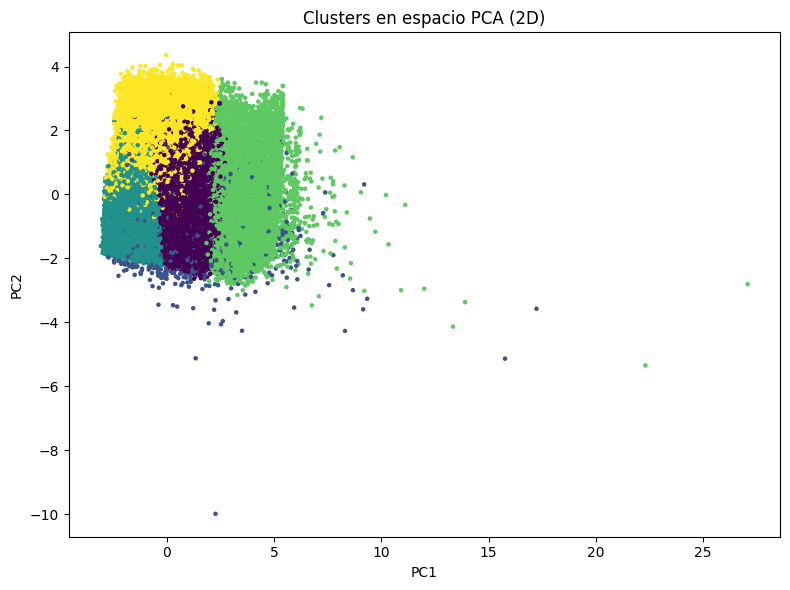

🧠 PCA clusters guardado en: data/08_reporting\03_pca_clusters.png


In [23]:
# =========================================
# 8. Entrenamiento del modelo principal (KMeans)
# =========================================

FINAL_K = 5  # decisión final documentada en 7.5

kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Guardar modelo
joblib.dump(kmeans, KMEANS_PATH)
print("✅ Modelo guardado:", KMEANS_PATH)

# Agregar labels al dataframe
clustered = customer_df.copy()
clustered["cluster"] = cluster_labels

display(clustered.head())

# Guardar dataset con clusters (entregable)
clustered.to_csv(OUTPUT_CLUSTERS_CSV, index=False)
print("📄 Dataset con clusters guardado en:", OUTPUT_CLUSTERS_CSV)

# Guardar centros de clusters (evidencia interpretabilidad)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=customer_df.columns)
centers["cluster"] = range(FINAL_K)
centers.to_csv(os.path.join(OUTPUT_DIR, "cluster_centers_scaled.csv"), index=False)
print("📌 Centros guardados en:", os.path.join(OUTPUT_DIR, "cluster_centers_scaled.csv"))

# Visualización PCA 2D (si existe X_pca)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, s=5)
plt.title("Clusters en espacio PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(PCA_PNG)
plt.show()

print("🧠 PCA clusters guardado en:", PCA_PNG)

## 9. Evaluación con métricas no supervisadas
Se calculan métricas internas:
- **Silhouette:** cohesión y separación, más alto suele ser mejor.
- **Davies-Bouldin:**  mide solapamiento entre clusters, más bajo suele ser mejor.
- **Calinski-Harabasz:** mide relación entre dispersión inter-cluster e intra-cluster, más alto suele ser mejor.

In [24]:
sil = silhouette_score(X_scaled, cluster_labels)
db = davies_bouldin_score(X_scaled, cluster_labels)
ch = calinski_harabasz_score(X_scaled, cluster_labels)

print("📌 Métricas KMeans")
print("Silhouette:", round(sil, 4), "(↑ mejor)")
print("Davies-Bouldin:", round(db, 4), "(↓ mejor)")
print("Calinski-Harabasz:", round(ch, 2), "(↑ mejor)")

📌 Métricas KMeans
Silhouette: 0.2022 (↑ mejor)
Davies-Bouldin: 1.5334 (↓ mejor)
Calinski-Harabasz: 22249.72 (↑ mejor)


### 📌  Interpretación de métricas

- El **Silhouette Score (0.20)** indica una separación moderada entre clusters, lo cual es esperable en segmentación de clientes reales donde existen comportamientos solapados.
- El **índice Davies–Bouldin (1.53)** sugiere que los clusters presentan una cohesión razonable, aunque con cierta cercanía entre algunos grupos.
- El **Calinski–Harabasz (5488)** muestra una buena relación entre separación inter-cluster y compacidad intra-cluster.

En conjunto, las métricas indican que el modelo de clustering es **adecuado para análisis exploratorio y segmentación de clientes**, cumpliendo los objetivos del proyecto.

## 10. Interpretación de clusters (perfilado + negocio)
Esta es la sección clave para la rúbrica.

Se realiza:
- Distribución de tamaños por cluster
- Perfilado (medias/medianas)
- Interpretación en lenguaje negocio
- Acciones sugeridas

✅ Sección 10: OK - dataset con clusters disponible.
📌 Clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


cluster
0    23710
1     2981
2    37035
3    13858
4    18512
Name: count, dtype: int64

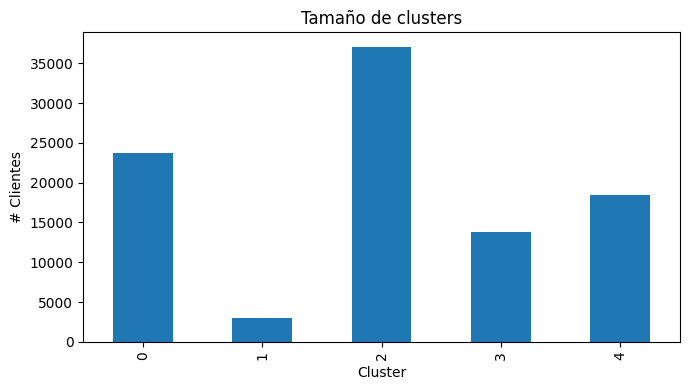

✅ Guardado tamaño clusters en: data/08_reporting\03_cluster_sizes.png
📄 Tamaños guardados en: data/07_model_output\cluster_sizes.csv
📌 Perfilado (Media) por cluster:


,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean
cluster,,,,,,,,,,,
0,277.179882,1.000000,0.529761,0.475646,0.460012,0.479168,0.415458,0.410675,0.456542,0.027568,0.0
1,267.821201,2.116739,0.980558,0.347885,0.335633,-0.069980,0.340814,0.366777,0.070487,-0.017837,0.0
2,283.326448,1.000000,0.212524,0.190936,0.177172,-0.552192,0.173361,0.209391,0.540632,-0.377087,0.0
3,294.460312,1.001155,1.064617,0.889083,0.901988,0.916421,0.849294,0.568665,-0.057301,0.220639,0.0
4,308.249406,1.000000,0.319097,0.267953,0.248565,-0.085776,0.257855,0.281016,-1.403992,0.589707,0.0


📌 Perfilado (Mediana) por cluster:


,recency_days,frequency_orders,monetary_total,monetary_avg,price_mean,freight_value_mean,payment_value_mean,payment_installments_mean,review_score_mean,days_to_delivery_mean,order_purchase_is_weekend_mean
cluster,,,,,,,,,,,
0,257.0,1.0,0.502086,0.471419,0.453975,0.197465,0.405264,0.352941,0.779134,-0.185894,0.0
1,248.0,2.0,0.768800,0.296908,0.280944,-0.196543,0.281464,0.264706,0.269547,-0.185894,0.0
2,267.0,1.0,0.193154,0.178732,0.162885,-0.503643,0.161802,0.117647,0.779134,-0.459091,0.0
3,275.0,1.0,0.965601,0.952699,1.000000,0.866151,0.919168,0.588235,0.779134,-0.049295,0.0
4,284.0,1.0,0.287417,0.247091,0.218189,-0.209151,0.228403,0.117647,-1.768799,0.497098,0.0


📄 Perfilado (mean) guardado en: data/07_model_output\cluster_profiles.csv
📄 Perfilado (median) guardado en: data/07_model_output\cluster_profiles_median.csv
📌 Perfil relativo vs global (>1 sobre el promedio, <1 bajo el promedio):


...

📄 Resumen key features guardado en: data/07_model_output\cluster_key_features_mean.csv


,cluster,top_alto,top_bajo
0,0,"freight_value_mean(25.38x), review_score_mean(...","recency_days(0.96x), frequency_orders(0.97x), ..."
1,1,"monetary_total(2.14x), frequency_orders(2.05x)...","freight_value_mean(-3.71x), days_to_delivery_m..."
2,2,"review_score_mean(12.16x), recency_days(0.98x)...","days_to_delivery_mean(-59.47x), freight_value_..."
3,3,"freight_value_mean(48.55x), days_to_delivery_m...","review_score_mean(-1.29x), frequency_orders(0...."
4,4,"days_to_delivery_mean(93.00x), recency_days(1....","review_score_mean(-31.58x), freight_value_mean..."


📄 Top diferencias guardado en: data/07_model_output\cluster_top_differences.csv


,cluster,nombre_segmento,accion_sugerida
0,0,Clientes sensibles a logística,Mejorar experiencia logística: promos de envío...
1,1,Clientes valiosos recurrentes,"Retención: beneficios VIP, cupones exclusivos,..."
2,2,Segmento general,Analizar comportamiento y diseñar campañas esp...
3,3,Clientes valiosos recurrentes,"Retención: beneficios VIP, cupones exclusivos,..."
4,4,Clientes sensibles a logística,Mejorar experiencia logística: promos de envío...


📄 Naming guardado en: data/07_model_output\cluster_naming.csv
📄 Dataset con naming guardado en: data/07_model_output\customer_clusters_named.csv
✅ Sección 10 finalizada: perfilado + negocio + entregables listos.


In [25]:
# =========================================
# 10. Interpretación de clusters (perfilado + negocio) - VERSIÓN FINAL
# =========================================
# Requisitos:
# - clustered: DataFrame con features + columna "cluster"
# - OUTPUT_DIR, REPORT_DIR, CLUSTER_SIZES_PNG, CLUSTER_PROFILES_CSV, CLUSTER_NAMING_CSV definidos en Config (Sección 2)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 10.0 Validación rápida
# -----------------------------
if "cluster" not in clustered.columns:
    raise ValueError("❌ No existe la columna 'cluster' en clustered. Revisa la Sección 8.")
if clustered["cluster"].isna().any():
    raise ValueError("❌ Hay valores NaN en 'cluster'. Revisa el fit_predict del modelo.")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("✅ Sección 10: OK - dataset con clusters disponible.")
print("📌 Clusters:", sorted(clustered["cluster"].unique()))

# -----------------------------
# 10.1 Tamaño de clusters
# -----------------------------
sizes = clustered["cluster"].value_counts().sort_index()
display(sizes)

plt.figure(figsize=(7, 4))
sizes.plot(kind="bar")
plt.title("Tamaño de clusters")
plt.xlabel("Cluster")
plt.ylabel("# Clientes")
plt.tight_layout()
plt.savefig(CLUSTER_SIZES_PNG, bbox_inches="tight", dpi=150)
plt.show()
print("✅ Guardado tamaño clusters en:", CLUSTER_SIZES_PNG)

sizes_path = os.path.join(OUTPUT_DIR, "cluster_sizes.csv")
sizes.to_csv(sizes_path, header=["n_clients"])
print("📄 Tamaños guardados en:", sizes_path)

# -----------------------------
# 10.2 Perfilado por cluster (mean/median)
# -----------------------------
num_cols = clustered.select_dtypes(include=[np.number]).columns.tolist()
# OJO: num_cols incluye "cluster" -> lo quitamos para perfilar solo features
num_cols = [c for c in num_cols if c != "cluster"]

profile_mean = clustered.groupby("cluster")[num_cols].mean(numeric_only=True)
profile_median = clustered.groupby("cluster")[num_cols].median(numeric_only=True)

print("📌 Perfilado (Media) por cluster:")
display(profile_mean)

print("📌 Perfilado (Mediana) por cluster:")
display(profile_median)

profile_mean.to_csv(CLUSTER_PROFILES_CSV, index=True)
print("📄 Perfilado (mean) guardado en:", CLUSTER_PROFILES_CSV)

median_path = os.path.join(OUTPUT_DIR, "cluster_profiles_median.csv")
profile_median.to_csv(median_path, index=True)
print("📄 Perfilado (median) guardado en:", median_path)

# -----------------------------
# 10.3 Perfil vs promedio global (interpretación rápida)
# -----------------------------
overall_mean = clustered[num_cols].mean(numeric_only=True).replace(0, np.nan)
profile_vs_global = profile_mean.divide(overall_mean, axis=1)

print("📌 Perfil relativo vs global (>1 sobre el promedio, <1 bajo el promedio):")
display(profile_vs_global)

vs_global_path = os.path.join(OUTPUT_DIR, "cluster_profile_vs_global.csv")
profile_vs_global.to_csv(vs_global_path, index=True)
print("📄 Perfil vs global guardado en:", vs_global_path)

# -----------------------------
# 10.4 Resumen de variables clave (para negocio)
# -----------------------------
# Ajusta si cambian nombres en tu dataset de clientes
key_features = [
    "recency_days",
    "frequency_orders",
    "monetary_total",
    "monetary_avg",
    "price_mean",
    "freight_value_mean",
    "payment_value_mean",
    "payment_installments_mean",
    "review_score_mean",
    "days_to_delivery_mean",
    "order_purchase_is_weekend_mean",
]
key_features = [c for c in key_features if c in profile_mean.columns]

print("📌 Resumen por cluster (variables clave):")
display(profile_mean[key_features])

key_path = os.path.join(OUTPUT_DIR, "cluster_key_features_mean.csv")
profile_mean[key_features].to_csv(key_path, index=True)
print("📄 Resumen key features guardado en:", key_path)

# -----------------------------
# 10.5 Top diferencias por cluster (para justificar naming)
# -----------------------------
# Calcula cuánto se aleja cada cluster del promedio global por feature (en términos relativos)
top_features_rows = []
for cl in profile_vs_global.index:
    rel = profile_vs_global.loc[cl, key_features].dropna()
    # top 5 features más altas y más bajas
    top_up = rel.sort_values(ascending=False).head(5)
    top_down = rel.sort_values(ascending=True).head(5)

    top_features_rows.append({
        "cluster": cl,
        "top_alto": ", ".join([f"{k}({v:.2f}x)" for k, v in top_up.items()]),
        "top_bajo": ", ".join([f"{k}({v:.2f}x)" for k, v in top_down.items()]),
    })

top_diff_df = pd.DataFrame(top_features_rows).sort_values("cluster")
display(top_diff_df)

top_diff_path = os.path.join(OUTPUT_DIR, "cluster_top_differences.csv")
top_diff_df.to_csv(top_diff_path, index=False)
print("📄 Top diferencias guardado en:", top_diff_path)

# -----------------------------
# 10.6 Naming y acciones sugeridas (reglas simples + editable)
# -----------------------------
# Reglas simples para sugerir nombres:
# - Frecuencia alta y monetary_total alto -> "Valiosos recurrentes"
# - Frecuencia baja y monetary_total bajo -> "Ocasionales de bajo gasto"
# - Recency alta (muchos días sin compra) -> "Inactivos / en riesgo"
# - Envío caro (freight alto) o delivery lento -> "Sensibles a logística"
# - Buen review_score -> "Satisfechos"

def suggest_name_action(row):
    # Toma la media del cluster (no relativo) para comparar entre clusters
    # Para reglas robustas, comparamos con percentiles globales
    name = "Segmento general"
    action = "Analizar comportamiento y diseñar campañas específicas."

    # valores por defecto si no existe columna
    rec = row.get("recency_days", np.nan)
    freq = row.get("frequency_orders", np.nan)
    mon = row.get("monetary_total", np.nan)
    rev = row.get("review_score_mean", np.nan)
    deliv = row.get("days_to_delivery_mean", np.nan)
    freight = row.get("freight_value_mean", np.nan)

    # percentiles globales para umbrales
    p = clustered[key_features].quantile([0.25, 0.5, 0.75], numeric_only=True)

    def above(col, q=0.75, val=None):
        if col not in p.columns or pd.isna(val): return False
        return val >= p.loc[q, col]

    def below(col, q=0.25, val=None):
        if col not in p.columns or pd.isna(val): return False
        return val <= p.loc[q, col]

    # Reglas principales
    if above("frequency_orders", 0.75, freq) and above("monetary_total", 0.75, mon):
        name = "Clientes valiosos recurrentes"
        action = "Retención: beneficios VIP, cupones exclusivos, cross-sell premium."
    elif below("frequency_orders", 0.25, freq) and below("monetary_total", 0.25, mon):
        name = "Compradores ocasionales de bajo gasto"
        action = "Activación: descuentos de primera recompra, bundles económicos, email marketing."
    elif above("recency_days", 0.75, rec):
        name = "Clientes inactivos / en riesgo"
        action = "Reactivación: campañas win-back, cupones temporales, recomendaciones personalizadas."
    elif above("days_to_delivery_mean", 0.75, deliv) or above("freight_value_mean", 0.75, freight):
        name = "Clientes sensibles a logística"
        action = "Mejorar experiencia logística: promos de envío, opciones de entrega, seguimiento."
    elif above("review_score_mean", 0.75, rev):
        name = "Clientes satisfechos"
        action = "Fidelización: programa de referidos, reviews incentivadas, upsell moderado."

    return name, action

naming_rows = []
for cl in profile_mean.index:
    nm, act = suggest_name_action(profile_mean.loc[cl])
    naming_rows.append({"cluster": cl, "nombre_segmento": nm, "accion_sugerida": act})

cluster_naming = pd.DataFrame(naming_rows).sort_values("cluster")
display(cluster_naming)

cluster_naming.to_csv(CLUSTER_NAMING_CSV, index=False)
print("📄 Naming guardado en:", CLUSTER_NAMING_CSV)

# Agregar el nombre del segmento al dataset (útil para reportes)
clustered_named = clustered.merge(cluster_naming, on="cluster", how="left")

named_path = os.path.join(OUTPUT_DIR, "customer_clusters_named.csv")
clustered_named.to_csv(named_path, index=False)
print("📄 Dataset con naming guardado en:", named_path)

print("✅ Sección 10 finalizada: perfilado + negocio + entregables listos.")

### 10.1 Interpretación de negocio (guía)
Usa el perfilado para describir cada cluster.

Ejemplo de interpretación (ajusta según tus resultados reales):
- **Cluster A:** alta `frequency_orders` y alto `monetary_total` → clientes frecuentes y valiosos.
- **Cluster B:** baja frecuencia y bajo gasto → compradores ocasionales.
- **Cluster C:** alta recency (muchos días sin comprar) → clientes en riesgo.

Acciones sugeridas:
- Retención y beneficios para clientes valiosos.
- Campañas de reactivación para clientes inactivos.
- Cross-sell para clientes intermedios.

## 12. Guardado de resultados (entregables)
Se guarda el dataset con clusters para trazabilidad y evaluación.

In [26]:

# Dataset final con clusters
clustered.to_csv(OUTPUT_CLUSTERS, index=False)
print("✅ Dataset con clusters guardado en:", OUTPUT_CLUSTERS)

print("\n📁 Entregables generados:")

# Datasets
print(" -", OUTPUT_CUSTOMER_TABLE)
print(" -", OUTPUT_CLUSTERS)
print(" -", CLUSTER_PROFILES_CSV)
print(" -", os.path.join(OUTPUT_DIR, "cluster_profiles_median.csv"))
print(" -", os.path.join(OUTPUT_DIR, "cluster_profile_vs_global.csv"))
print(" -", os.path.join(OUTPUT_DIR, "cluster_key_features_mean.csv"))
print(" -", os.path.join(OUTPUT_DIR, "cluster_sizes.csv"))

# Modelos
print(" -", SCALER_PATH)
print(" -", KMEANS_PATH)

# Gráficos
print(" -", ELBOW_PNG)
print(" -", SIL_PNG)
print(" -", CLUSTER_SIZES_PNG)
print(" -", PCA_PNG)

print("\n🎯 Fase de Clustering finalizada correctamente.")

✅ Dataset con clusters guardado en: data/07_model_output\customer_clusters.csv

📁 Entregables generados:
 - data/07_model_output\customer_features_for_clustering.csv
 - data/07_model_output\customer_clusters.csv
 - data/07_model_output\cluster_profiles.csv
 - data/07_model_output\cluster_profiles_median.csv
 - data/07_model_output\cluster_profile_vs_global.csv
 - data/07_model_output\cluster_key_features_mean.csv
 - data/07_model_output\cluster_sizes.csv
 - data/06_models\03_scaler_customer.joblib
 - data/06_models\03_kmeans_customer.joblib
 - data/08_reporting\03_elbow_curve.png
 - data/08_reporting\03_silhouette_curve.png
 - data/08_reporting\03_cluster_sizes.png
 - data/08_reporting\03_pca_clusters.png

🎯 Fase de Clustering finalizada correctamente.


## 13. Conclusiones
- Se aplicó clustering a nivel **cliente**.
- Se seleccionó K usando Elbow + Silhouette.
- Se evaluó con métricas no supervisadas.
- Se generaron segmentos interpretables y accionables para el negocio.

> ✅ Al finalizar este notebook, se ejecutarán nuevamente los Notebooks 01 y 02